In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [2]:
# Device configuration (use GPU if available)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [3]:
# Hyperparameters
input_size = 784  # 28*28
hidden_size = 128
num_classes = 10
num_epochs = 5
batch_size = 100
learning_rate = 0.001

# MNIST dataset
train_dataset = datasets.MNIST(root='./data',
                               train=True,
                               transform=transforms.ToTensor(),
                               download=True)

test_dataset = datasets.MNIST(root='./data',
                              train=False,
                              transform=transforms.ToTensor())

100%|██████████| 9.91M/9.91M [00:00<00:00, 55.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.67MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.7MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.39MB/s]


In [4]:
# Data loaders
train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

In [5]:
# Define the neural network model
class NeuralNet(nn.Module):
    def __init__(self, activation_func):
        super(NeuralNet, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)

        # Select the activation function based on the input string
        if activation_func == 'relu':
            self.activation = nn.ReLU()
        elif activation_func == 'tanh':
            self.activation = nn.Tanh()
        elif activation_func == 'sigmoid':
            self.activation = nn.Sigmoid()
        elif activation_func == 'softmax':
            self.activation = nn.Softmax()
        else:
            raise ValueError("Unsupported activation function")

        self.fc2 = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        out = self.fc1(x)
        out = self.activation(out)
        out = self.fc2(out)
        return out

In [6]:
# Training and evaluation function
def train_and_evaluate(model, num_epochs, name):
    print(f"--- Training with {name} activation ---")
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    # Train the model
    total_step = len(train_loader)
    loss_values = [] # List to store loss values
    for epoch in range(num_epochs):
        for i, (images, labels) in enumerate(train_loader):
            # Reshape images to (batch_size, input_size)
            images = images.reshape(-1, 28 * 28).to(device)
            labels = labels.to(device)

            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss_values.append(loss.item()) # Store loss value

            # Backward and optimize
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            if (i + 1) % 100 == 0:
                print(f'Epoch [{epoch + 1}/{num_epochs}], Step [{i + 1}/{total_step}], Loss: {loss.item():.4f}')

    # Test the model
    with torch.no_grad():
        correct = 0
        total = 0
        for images, labels in test_loader:
            images = images.reshape(-1, 28 * 28).to(device)
            labels = labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        print(f'Accuracy of the model on the 10000 test images: {100 * correct / total:.2f} %')
    print("---------------------------------------")
    return loss_values # Return the list of loss values

--- Training with ReLU activation ---
Epoch [1/5], Step [100/600], Loss: 0.4945
Epoch [1/5], Step [200/600], Loss: 0.2419
Epoch [1/5], Step [300/600], Loss: 0.1906
Epoch [1/5], Step [400/600], Loss: 0.2545
Epoch [1/5], Step [500/600], Loss: 0.2621
Epoch [1/5], Step [600/600], Loss: 0.2563
Epoch [2/5], Step [100/600], Loss: 0.1846
Epoch [2/5], Step [200/600], Loss: 0.0895
Epoch [2/5], Step [300/600], Loss: 0.1556
Epoch [2/5], Step [400/600], Loss: 0.2780
Epoch [2/5], Step [500/600], Loss: 0.1632
Epoch [2/5], Step [600/600], Loss: 0.1860
Epoch [3/5], Step [100/600], Loss: 0.2270
Epoch [3/5], Step [200/600], Loss: 0.1670
Epoch [3/5], Step [300/600], Loss: 0.1151
Epoch [3/5], Step [400/600], Loss: 0.1062
Epoch [3/5], Step [500/600], Loss: 0.2385
Epoch [3/5], Step [600/600], Loss: 0.1201
Epoch [4/5], Step [100/600], Loss: 0.0720
Epoch [4/5], Step [200/600], Loss: 0.0934
Epoch [4/5], Step [300/600], Loss: 0.1118
Epoch [4/5], Step [400/600], Loss: 0.0441
Epoch [4/5], Step [500/600], Loss: 0.1

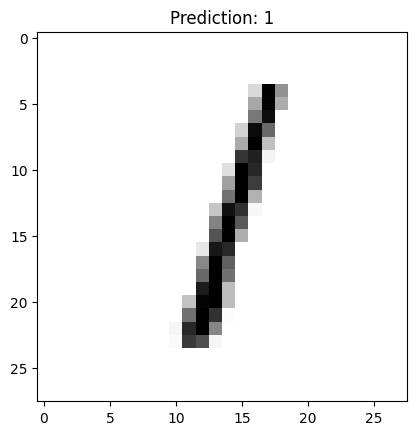

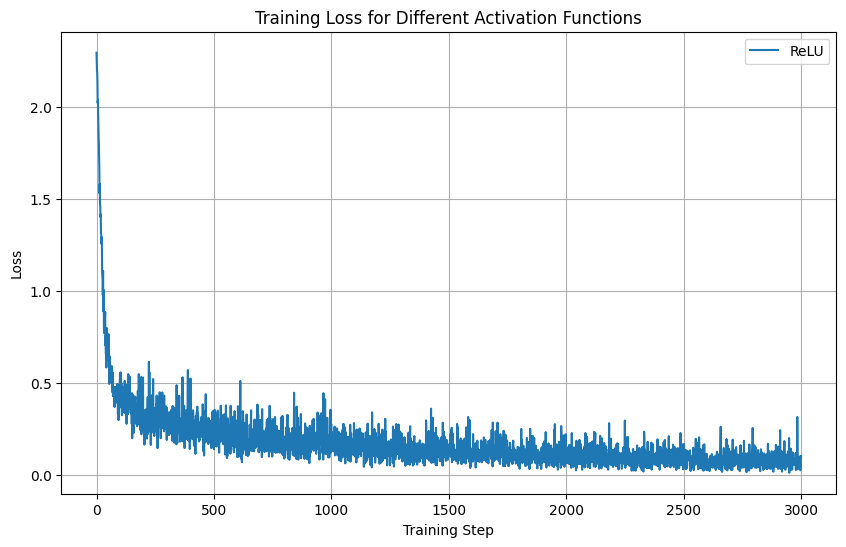

In [7]:
# Instantiate and train models with different activation functions
model_relu = NeuralNet('relu').to(device)
loss_relu = train_and_evaluate(model_relu, num_epochs, 'ReLU')

# Visualizing a Prediction
# Get a single batch of test images
dataiter = iter(test_loader)
images, labels = next(dataiter)

# Make a prediction on the first image
pre=2
with torch.no_grad():
    img_for_pred = images[pre].reshape(-1, 28*28).to(device)
    output = model_relu(img_for_pred) # Use model_relu for prediction
    _, prediction = torch.max(output.data, 1)

# Display the image and the prediction
plt.imshow(images[pre].numpy().squeeze(), cmap='gray_r')
plt.title(f'Prediction: {prediction.item()}')
plt.show()

# Plotting the loss curves
plt.figure(figsize=(10, 6))
plt.plot(loss_relu, label='ReLU')

plt.xlabel('Training Step')
plt.ylabel('Loss')
plt.title('Training Loss for Different Activation Functions')
plt.legend()
plt.grid(True)
plt.show()

--- Training with Tanh activation ---
Epoch [1/5], Step [100/600], Loss: 0.3833
Epoch [1/5], Step [200/600], Loss: 0.1830
Epoch [1/5], Step [300/600], Loss: 0.2379
Epoch [1/5], Step [400/600], Loss: 0.2142
Epoch [1/5], Step [500/600], Loss: 0.2371
Epoch [1/5], Step [600/600], Loss: 0.2989
Epoch [2/5], Step [100/600], Loss: 0.2149
Epoch [2/5], Step [200/600], Loss: 0.2567
Epoch [2/5], Step [300/600], Loss: 0.0918
Epoch [2/5], Step [400/600], Loss: 0.1451
Epoch [2/5], Step [500/600], Loss: 0.1716
Epoch [2/5], Step [600/600], Loss: 0.1418
Epoch [3/5], Step [100/600], Loss: 0.1580
Epoch [3/5], Step [200/600], Loss: 0.1695
Epoch [3/5], Step [300/600], Loss: 0.0826
Epoch [3/5], Step [400/600], Loss: 0.0916
Epoch [3/5], Step [500/600], Loss: 0.1118
Epoch [3/5], Step [600/600], Loss: 0.0729
Epoch [4/5], Step [100/600], Loss: 0.1254
Epoch [4/5], Step [200/600], Loss: 0.1760
Epoch [4/5], Step [300/600], Loss: 0.0545
Epoch [4/5], Step [400/600], Loss: 0.1429
Epoch [4/5], Step [500/600], Loss: 0.1

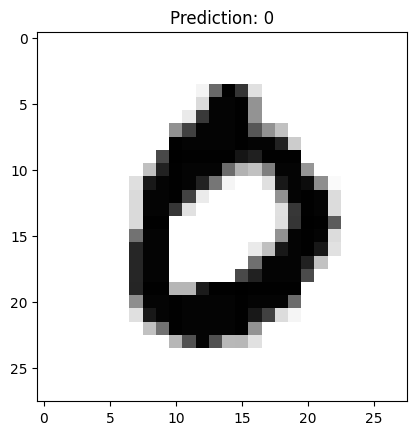

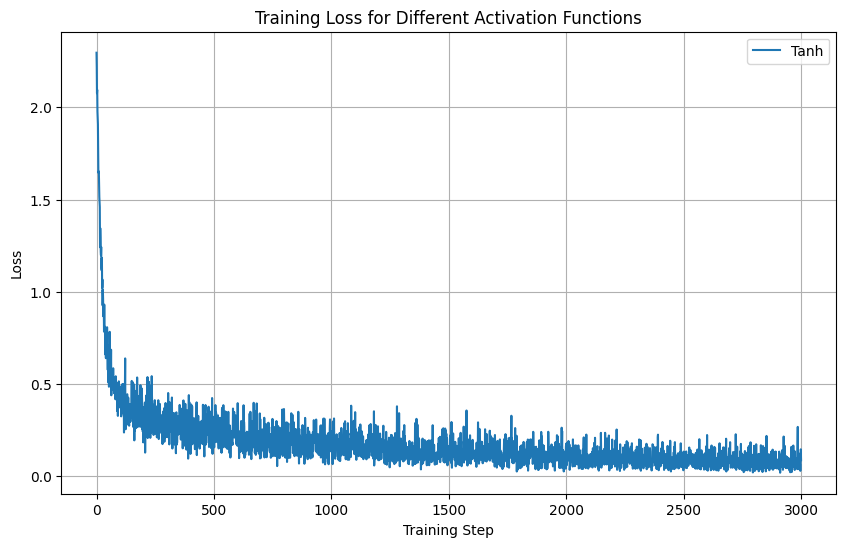

In [8]:
model_tanh = NeuralNet('tanh').to(device)
loss_tanh = train_and_evaluate(model_tanh, num_epochs, 'Tanh')

# Visualizing a Prediction
# Get a single batch of test images
dataiter = iter(test_loader)
images, labels = next(dataiter)

# Make a prediction on the first image
pre=3
with torch.no_grad():
    img_for_pred = images[pre].reshape(-1, 28*28).to(device)
    output = model_tanh(img_for_pred) # Use model_tanh for prediction
    _, prediction = torch.max(output.data, 1)

# Display the image and the prediction
plt.imshow(images[pre].numpy().squeeze(), cmap='gray_r')
plt.title(f'Prediction: {prediction.item()}')
plt.show()

# Plotting the loss curves
plt.figure(figsize=(10, 6))
plt.plot(loss_tanh, label='Tanh')

plt.xlabel('Training Step')
plt.ylabel('Loss')
plt.title('Training Loss for Different Activation Functions')
plt.legend()
plt.grid(True)
plt.show()

--- Training with Sigmoid activation ---
Epoch [1/5], Step [100/600], Loss: 1.0532
Epoch [1/5], Step [200/600], Loss: 0.4979
Epoch [1/5], Step [300/600], Loss: 0.4294
Epoch [1/5], Step [400/600], Loss: 0.3686
Epoch [1/5], Step [500/600], Loss: 0.2807
Epoch [1/5], Step [600/600], Loss: 0.3277
Epoch [2/5], Step [100/600], Loss: 0.2165
Epoch [2/5], Step [200/600], Loss: 0.2291
Epoch [2/5], Step [300/600], Loss: 0.3091
Epoch [2/5], Step [400/600], Loss: 0.2703
Epoch [2/5], Step [500/600], Loss: 0.2776
Epoch [2/5], Step [600/600], Loss: 0.2817
Epoch [3/5], Step [100/600], Loss: 0.2680
Epoch [3/5], Step [200/600], Loss: 0.1457
Epoch [3/5], Step [300/600], Loss: 0.1689
Epoch [3/5], Step [400/600], Loss: 0.2162
Epoch [3/5], Step [500/600], Loss: 0.2034
Epoch [3/5], Step [600/600], Loss: 0.1594
Epoch [4/5], Step [100/600], Loss: 0.1684
Epoch [4/5], Step [200/600], Loss: 0.2015
Epoch [4/5], Step [300/600], Loss: 0.3070
Epoch [4/5], Step [400/600], Loss: 0.1024
Epoch [4/5], Step [500/600], Loss: 

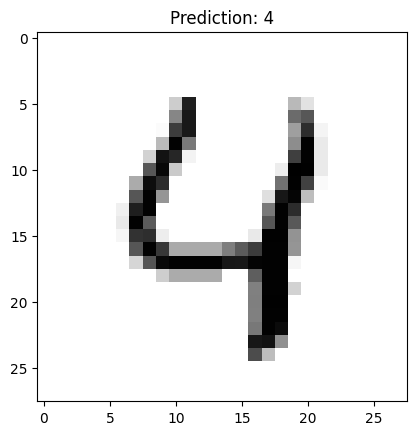

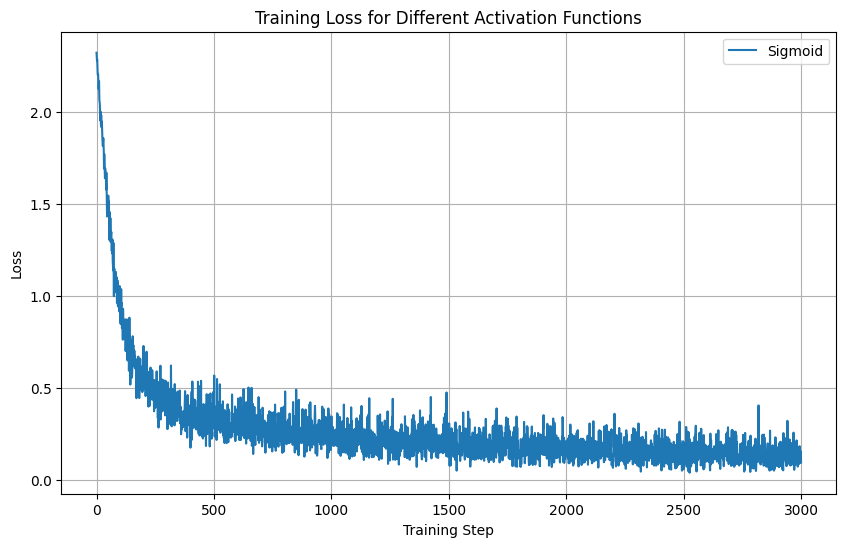

In [9]:
model_sigmoid = NeuralNet('sigmoid').to(device)
loss_sigmoid = train_and_evaluate(model_sigmoid, num_epochs, 'Sigmoid')

# Visualizing a Prediction
# Get a single batch of test images
dataiter = iter(test_loader)
images, labels = next(dataiter)

# Make a prediction on the first image
pre=4
with torch.no_grad():
    img_for_pred = images[pre].reshape(-1, 28*28).to(device)
    output = model_sigmoid(img_for_pred) # Use model_sigmoid for prediction
    _, prediction = torch.max(output.data, 1)

# Display the image and the prediction
plt.imshow(images[pre].numpy().squeeze(), cmap='gray_r')
plt.title(f'Prediction: {prediction.item()}')
plt.show()

# Plotting the loss curves
plt.figure(figsize=(10, 6))
plt.plot(loss_sigmoid, label='Sigmoid')

plt.xlabel('Training Step')
plt.ylabel('Loss')
plt.title('Training Loss for Different Activation Functions')
plt.legend()
plt.grid(True)
plt.show()

--- Training with Softmax activation ---


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1773: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


Epoch [1/5], Step [100/600], Loss: 2.1284
Epoch [1/5], Step [200/600], Loss: 1.8894
Epoch [1/5], Step [300/600], Loss: 1.7155
Epoch [1/5], Step [400/600], Loss: 1.5790
Epoch [1/5], Step [500/600], Loss: 1.4585
Epoch [1/5], Step [600/600], Loss: 1.3526
Epoch [2/5], Step [100/600], Loss: 1.2759
Epoch [2/5], Step [200/600], Loss: 1.1289
Epoch [2/5], Step [300/600], Loss: 1.1022
Epoch [2/5], Step [400/600], Loss: 0.9536
Epoch [2/5], Step [500/600], Loss: 0.9593
Epoch [2/5], Step [600/600], Loss: 0.8600
Epoch [3/5], Step [100/600], Loss: 0.7701
Epoch [3/5], Step [200/600], Loss: 0.7841
Epoch [3/5], Step [300/600], Loss: 0.6940
Epoch [3/5], Step [400/600], Loss: 0.7841
Epoch [3/5], Step [500/600], Loss: 0.7095
Epoch [3/5], Step [600/600], Loss: 0.6004
Epoch [4/5], Step [100/600], Loss: 0.5771
Epoch [4/5], Step [200/600], Loss: 0.6425
Epoch [4/5], Step [300/600], Loss: 0.5800
Epoch [4/5], Step [400/600], Loss: 0.5798
Epoch [4/5], Step [500/600], Loss: 0.4774
Epoch [4/5], Step [600/600], Loss:

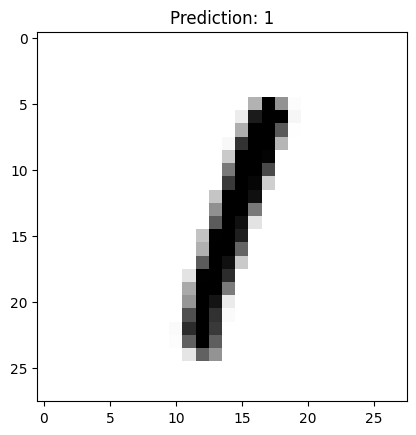

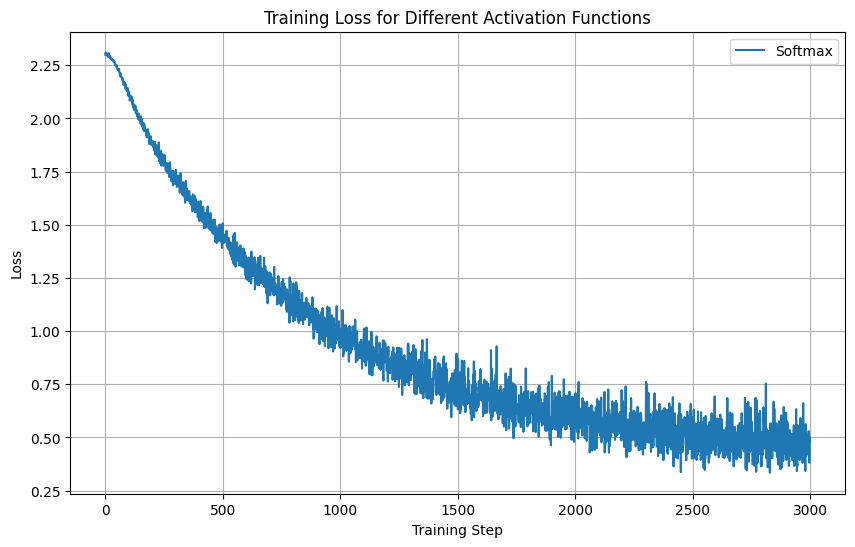

In [10]:
model_softmax = NeuralNet('softmax').to(device)
loss_softmax = train_and_evaluate(model_softmax, num_epochs, 'Softmax')

# Visualizing a Prediction
# Get a single batch of test images
dataiter = iter(test_loader)
images, labels = next(dataiter)

# Make a prediction on the first image
pre=5
with torch.no_grad():
    img_for_pred = images[pre].reshape(-1, 28*28).to(device)
    output = model_softmax(img_for_pred) # Use model_softmax for prediction
    _, prediction = torch.max(output.data, 1)

# Display the image and the prediction
plt.imshow(images[pre].numpy().squeeze(), cmap='gray_r')
plt.title(f'Prediction: {prediction.item()}')
plt.show()

# Plotting the loss curves
plt.figure(figsize=(10, 6))
plt.plot(loss_softmax, label='Softmax')

plt.xlabel('Training Step')
plt.ylabel('Loss')
plt.title('Training Loss for Different Activation Functions')
plt.legend()
plt.grid(True)
plt.show()

--- Training with ReLU activation ---
Epoch [1/5], Step [100/600], Loss: 0.4975
Epoch [1/5], Step [200/600], Loss: 0.3530
Epoch [1/5], Step [300/600], Loss: 0.3400
Epoch [1/5], Step [400/600], Loss: 0.2275
Epoch [1/5], Step [500/600], Loss: 0.1949
Epoch [1/5], Step [600/600], Loss: 0.2954
Epoch [2/5], Step [100/600], Loss: 0.2813
Epoch [2/5], Step [200/600], Loss: 0.1639
Epoch [2/5], Step [300/600], Loss: 0.2156
Epoch [2/5], Step [400/600], Loss: 0.1158
Epoch [2/5], Step [500/600], Loss: 0.2377
Epoch [2/5], Step [600/600], Loss: 0.0710
Epoch [3/5], Step [100/600], Loss: 0.1279
Epoch [3/5], Step [200/600], Loss: 0.1503
Epoch [3/5], Step [300/600], Loss: 0.0648
Epoch [3/5], Step [400/600], Loss: 0.0707
Epoch [3/5], Step [500/600], Loss: 0.2223
Epoch [3/5], Step [600/600], Loss: 0.2229
Epoch [4/5], Step [100/600], Loss: 0.1027
Epoch [4/5], Step [200/600], Loss: 0.1127
Epoch [4/5], Step [300/600], Loss: 0.1092
Epoch [4/5], Step [400/600], Loss: 0.0691
Epoch [4/5], Step [500/600], Loss: 0.0

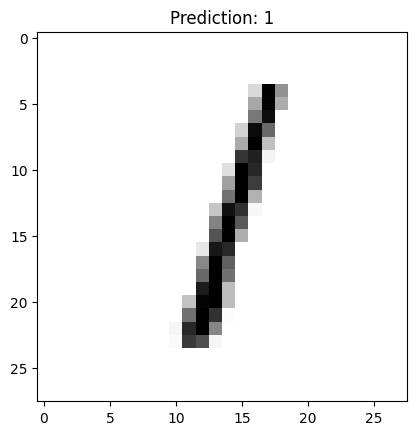

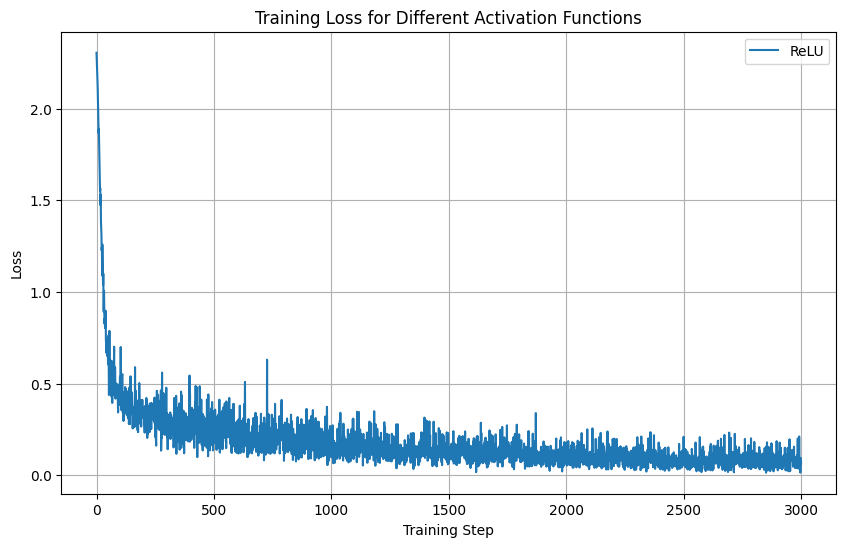

In [11]:
# Instantiate and train models with different activation functions
model_relu = NeuralNet('relu').to(device)
loss_relu = train_and_evaluate(model_relu, num_epochs, 'ReLU')

# Visualizing a Prediction
# Get a single batch of test images
dataiter = iter(test_loader)
images, labels = next(dataiter)

# Make a prediction on the first image
pre=2
with torch.no_grad():
    img_for_pred = images[pre].reshape(-1, 28*28).to(device)
    output = model_relu(img_for_pred) # Use model_relu for prediction
    _, prediction = torch.max(output.data, 1)

# Display the image and the prediction
plt.imshow(images[pre].numpy().squeeze(), cmap='gray_r')
plt.title(f'Prediction: {prediction.item()}')
plt.show()

# Plotting the loss curves
plt.figure(figsize=(10, 6))
plt.plot(loss_relu, label='ReLU')

plt.xlabel('Training Step')
plt.ylabel('Loss')
plt.title('Training Loss for Different Activation Functions')
plt.legend()
plt.grid(True)
plt.show()